<a href="https://colab.research.google.com/github/ZethRodaje/Phishing-Website-Detection-Using-Machine-Learning/blob/main/Phishing_Website_Detection_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phishing Website Detection Using Machine Learning**

**0. Setup and Config**

In [1]:
!pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
import sklearn, sys
print(sys.version, sklearn.__version__)

3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0] 1.9.1


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import re
import joblib
from urllib.parse import urlparse

from sklearn.base import clone
from sklearn.model_selection import (train_test_split, StratifiedKFold, StratifiedGroupKFold, cross_validate,
                                     cross_val_predict, RandomizedSearchCV, GridSearchCV)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, make_scorer, roc_auc_score, average_precision_score)

RANDOM_STATE = 42

# True  = smaller hyperparameter search (minutes, used to produce the shipped model file here).
# False = full search from the original milestone (slow; run this in Colab for the final submission).
QUICK_RUN = False
IP_RE = re.compile(r"^(\d{1,3}\.){3}\d{1,3}$")

**1. Load and Inspect**

In [4]:
df = pd.read_csv("phishing_features.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (160064, 13)


,url,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,tld,special_char_count,digits_count,entropy
0,http://forum.uk.securebankinggroup.com/107519/...,1,89,3,0,0,5,0,2,com,4,29,4.792985
1,http://b45042.com/fish/29,1,25,1,0,0,4,0,0,com,0,7,4.003856
2,http://bet73018.com/lottery/99,1,30,1,0,0,4,0,0,com,0,7,4.053236
3,https://logiin--metsa-autho.webflow.io/,1,39,2,1,0,3,0,0,io,3,0,4.150411
4,https://mettamasklogiiann.webflow.io/,1,37,2,1,0,3,0,0,io,0,0,4.100817


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True) * 100)

Missing values:
url                     0
label                   0
url_length              0
num_dots                0
has_https               0
has_ip                  0
num_subdirs             0
num_params              0
suspicious_words        0
tld                   821
special_char_count      0
digits_count            0
entropy                 0
dtype: int64

Duplicate rows: 0

Label distribution:
label
1    159244
0       820
Name: count, dtype: int64
label
1    99.487705
0     0.512295
Name: proportion, dtype: float64


**2. Clean the Data**

In [6]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Duplicates removed: {before - after} ({before} -> {after} rows)")

# The raw 'tld' column is unreliable: it is missing for all 820 benign rows and holds junk
# values (like "202") for IP hosts. It is rebuilt from the host in section 3.5, so this
# fill is only a placeholder.
df["tld"] = df["tld"].fillna("unknown")
print("Remaining missing values:", df.isnull().sum().sum())

Duplicates removed: 0 (160064 -> 160064 rows)
Remaining missing values: 0


**3. Check for Data Leakage**

In [7]:
numeric_features = ["url_length", "num_dots", "has_https", "has_ip", "num_subdirs",
                     "num_params", "suspicious_words", "special_char_count", "digits_count", "entropy"]

print("Feature correlation with label:")
print(df[numeric_features + ["label"]].corr()["label"].sort_values(key=abs, ascending=False))

print("\nChecking each feature for a perfectly-separating value range:")
for col in numeric_features:
    benign_vals = df.loc[df["label"] == 0, col]
    phishing_vals = df.loc[df["label"] == 1, col]
    if benign_vals.max() < phishing_vals.min() or phishing_vals.max() < benign_vals.min():
        print(f"  PERFECT SEPARATION on '{col}': benign [{benign_vals.min()}, {benign_vals.max()}], "
              f"phishing [{phishing_vals.min()}, {phishing_vals.max()}]")

Feature correlation with label:
label                 1.000000
num_subdirs           0.141735
entropy               0.133363
num_dots              0.125898
has_ip                0.069704
has_https             0.062848
digits_count          0.047991
url_length            0.028927
special_char_count    0.028911
num_params            0.016988
suspicious_words      0.008595
Name: label, dtype: float64

Checking each feature for a perfectly-separating value range:
  PERFECT SEPARATION on 'num_subdirs': benign [0, 0], phishing [2, 104]


**Digging deeper: why does num_subdirs show zero overlap?**

A feature that separates the classes perfectly is a warning sign. It is worth checking why before simply dropping it.

In [8]:
print("Does any benign URL have a scheme (://)?", df.loc[df.label == 0, "url"].str.contains("://").any())
print("Do all phishing URLs have a scheme (://)?", df.loc[df.label == 1, "url"].str.contains("://").all())
print()
print("num_subdirs by class:")
print(df.groupby("label")["num_subdirs"].describe()[["mean", "std", "min", "max"]])
print()
print("Sample benign URLs (note: bare domains, no scheme, no path):")
print(df.loc[df.label == 0, "url"].sample(8, random_state=1).tolist())

Does any benign URL have a scheme (://)? False
Do all phishing URLs have a scheme (://)? True

num_subdirs by class:
           mean       std  min    max
label                                
0      0.000000  0.000000  0.0    0.0
1      4.149695  2.074399  2.0  104.0

Sample benign URLs (note: bare domains, no scheme, no path):
['shopify.com', 'trustedsite65.org', 'adobe.com', 'kaist.ac.kr', 'gov.cn', 'leetcode.com', 'atlassian.com', 'kaggle.com']


**Root cause found:** none of the 820 benign URLs carry a scheme (http:// or https://). They are bare domains like shopify.com, adobe.com and kaggle.com. This collection artifact explains more than just num_subdirs. has_https, num_params and suspicious_words do not measure phishing behavior for these rows. They only show which source list a URL came from (a full phishing feed URL or a bare-domain benign list). A model trained on them learns a shortcut instead of a real signal, even for features that did not show up as perfectly separating in the simple range check above.

**3.5. Normalize URLs and Rebuild Features From the Host**

**Note on the tld column:** In the raw data, tld is missing for 820 of the 821 rows with a missing value, and all 820 are benign. It also holds junk values for IP hosts (for example "202"). Used as is, it would let a model separate the classes by which source list a row came from. The column is therefore rebuilt from the host name: IP hosts become "ip_address" and every other host gets its last label (such as "com" or "org"). The result is turned into a frequency feature (tld_freq) using training data only.

Every URL is reduced to its host name. The host is lowercased and a leading "www." is removed. None of the benign hosts in this dataset start with "www.", so leaving it in teaches the model that "www." means phishing. The feature set also includes extra host-name features (label lengths, digit runs, ratios, and a suspicious-word flag) alongside the original ones.

In [14]:
SUSP_WORDS = ["login", "signin", "secure", "verify", "account", "update", "banking", "confirm",
              "webscr", "password", "support", "billing", "recover", "unlock", "alert", "suspend"]

def normalize_host(u):
    u = u.strip()
    if "://" not in u:
        u = "http://" + u  # benign rows have no scheme; the scheme itself is never used as a feature
    try:
        h = urlparse(u).netloc.split(":")[0].lower()  # strip port, keep bare host
    except ValueError:  # malformed input such as "http://[bad"; treated as "no host found"
        return ""
    if h.startswith("www.") and h.count(".") >= 2:
        h = h[4:]  # drop a leading www. so it cannot act as a dataset shortcut
    return h

def shannon_entropy(s):
    if not s:
        return 0.0
    probs = [s.count(c) / len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in probs)

SECOND_LEVEL = {"co", "com", "org", "net", "gov", "edu", "ac", "or", "ne", "go", "mil"}

def suffix_len(host):
    """Labels in the public suffix: 2 for endings like co.uk, com.ph, edu.ph, gov.ph; otherwise 1."""
    parts = host.split(".")
    return 2 if len(parts) >= 3 and len(parts[-1]) == 2 and parts[-2] in SECOND_LEVEL else 1

def get_tld(host):
    if IP_RE.match(host):
        return "ip_address"
    parts = host.split(".")
    if len(parts) < 2:
        return "unknown"
    return ".".join(parts[-suffix_len(host):])  # "edu.ph", "com.ph", "co.uk" keep their full ending

def host_features(h):
    is_ip = bool(IP_RE.match(h))
    labels = h.split(".") if h else [""]
    n = max(len(h), 1)
    n_digits = len(re.findall(r"\d", h))
    n_hyphens = h.count("-")
    letters = re.findall(r"[a-z]", h)
    vowels = [ch for ch in letters if ch in "aeiou"]
    digit_runs = re.findall(r"\d+", h)
    return {
        "url_length": len(h),
        "num_dots": h.count("."),
        "has_ip": int(is_ip),
        "digits_count": n_digits,
        "num_hyphens": n_hyphens,
        "subdomain_count": 0 if is_ip else max(len(labels) - 1 - suffix_len(h), 0),
        "entropy": shannon_entropy(h),
        "num_labels": len(labels),
        "longest_label": max(len(x) for x in labels),
        "longest_digit_run": max((len(x) for x in digit_runs), default=0),
        "digit_ratio": n_digits / n,
        "hyphen_ratio": n_hyphens / n,
        "vowel_ratio": len(vowels) / len(letters) if letters else 0.0,
        "has_susp_word": int(any(w in h for w in SUSP_WORDS)),
        "tld": get_tld(h),
    }

raw_www = df["url"].str.lower().str.contains(r"^(?:\w+://)?www\.")
print("Share of URLs starting with www. BEFORE stripping, by class:")
print(raw_www.groupby(df["label"]).mean().round(4))

df["host"] = df["url"].map(normalize_host)
feats = pd.DataFrame([host_features(h) for h in df["host"]], index=df.index)
for col in feats.columns:
    df[col] = feats[col]

# Dropped entirely: has_https (unmeasurable for benign source), num_subdirs / num_params /
# suspicious_words (path-only features; benign URLs have no path to measure),
# special_char_count (importance was zero in the previous run)

feature_cols = [c for c in feats.columns if c != "tld"]

print("\nFeature means by class after normalization:")
print(df.groupby("label")[feature_cols].mean().T)

Share of URLs starting with www. BEFORE stripping, by class:
label
0    0.0000
1    0.0169
Name: url, dtype: float64

Feature means by class after normalization:
label                      0          1
url_length         14.078049  16.203204
num_dots            1.035366   2.365088
has_ip              0.000000   0.487296
digits_count        1.086585   5.994380
num_hyphens         0.004878   0.237773
subdomain_count     0.007317   0.386300
entropy             3.355376   3.014228
num_labels          2.035366   3.365088
longest_label      10.020732   6.939376
longest_digit_run   1.086585   1.933297
digit_ratio         0.065943   0.414221
hyphen_ratio        0.000353   0.011524
vowel_ratio         0.381350   0.177083
has_susp_word       0.000000   0.011398


---

After normalization, url_length is a host measurement for both classes, so benign hosts are no longer artificially short next to phishing URLs that include a path. The remaining differences (phishing hosts have more digits, more hyphens and more subdomains) reflect genuine domain naming patterns, not collection artifacts.

**3.6. Re-run the Leakage Check on the Normalized Features**

In [15]:
print("Checking each normalized feature for a perfectly-separating value range:")
found = False
for col in feature_cols:
    benign_vals = df.loc[df["label"] == 0, col]
    phishing_vals = df.loc[df["label"] == 1, col]
    if benign_vals.max() < phishing_vals.min() or phishing_vals.max() < benign_vals.min():
        found = True
        print(f"  PERFECT SEPARATION on '{col}'")
if not found:
    print("  None found. Features now overlap between classes as expected.")

Checking each normalized feature for a perfectly-separating value range:
  None found. Features now overlap between classes as expected.


**3.7. Curated Domain Knowledge, Rules and Host-Level Deduplication**

A host-only model cannot tell a page on a legitimate service from a phishing page on the same service. The dataset labels about 1,560 github.com rows and thousands of docs.google.com rows as phishing (pages hosted there), so a model trained on them learns "github.com = phishing". Legitimate sites such as chatgpt.com or up.edu.ph are also rare in the benign list.

Fixes, none of which edit phishing_features.csv:

1. **Trusted-domain list:** a hard-coded list of known legitimate registered domains, matched on the end of the host so look-alikes such as paypal.com.verify.xyz never match.
2. **Institutional suffix rule:** .edu, .gov, .mil, .edu.ph, .gov.ph, .ac.xx can only be registered by schools and governments. Open endings (.org, .com, plain .ph) are not trusted by ending alone, because the dataset has many phishing hosts on them.
3. **Brand impersonation rule:** a host that uses a well-known brand name but is not that brand's domain is phishing.
4. **Host-level deduplication:** after the URL is reduced to its host, rows with the same host and label are duplicates (for example 1,563 github.com rows that differ only in their path). Keeping one row per host and label stops a few popular hosts from dominating training. This is done in memory; the CSV is untouched.
5. **Extra legitimate training rows:** curated legitimate hosts (including .ph, .org, .edu and subdomain hosts) are added to the **training set only**, and a quarter of them is held back to measure how the model treats unseen legitimate hosts.

Rules run first, then the model decides everything the rules do not cover.

In [16]:
# ---------------------------------------------------------------------------------------------
# Curated knowledge used alongside the model. Nothing here changes phishing_features.csv.
# ---------------------------------------------------------------------------------------------

# 1) Registered domains that are known to be legitimate. A host matches when it IS the domain or a
#    subdomain of it (so "mail.google.com" matches, but "google.com.verify.xyz" and "evilgoogle.com" do not).
#    Free-hosting platforms where anyone can create a subdomain (github.io, weebly.com, web.app,
#    pages.dev, blogspot.com ...) are deliberately NOT in this list.
TRUSTED_DOMAINS = set("""
google.com google.com.ph youtube.com youtu.be gmail.com googleapis.com gstatic.com googleusercontent.com google-analytics.com
bing.com microsoft.com live.com outlook.com office.com office365.com microsoftonline.com windows.com azure.com
msn.com skype.com sharepoint.com onedrive.com apple.com icloud.com amazon.com amazonaws.com amazon.in amazon.co.uk
amazon.de amazon.com.au amazon.ca primevideo.com meta.com facebook.com fb.com messenger.com instagram.com
whatsapp.com threads.net x.com twitter.com linkedin.com reddit.com pinterest.com tiktok.com snapchat.com
telegram.org discord.com twitch.tv openai.com chatgpt.com anthropic.com claude.ai perplexity.ai github.com
gitlab.com bitbucket.org stackoverflow.com stackexchange.com npmjs.com pypi.org python.org nodejs.org oracle.com
docker.com kubernetes.io mozilla.org firefox.com wikipedia.org wikimedia.org wiktionary.org archive.org
cloudflare.com digitalocean.com heroku.com vercel.com netlify.com kaggle.com huggingface.co tensorflow.org
pytorch.org scikit-learn.org pydata.org numpy.org jupyter.org streamlit.io anaconda.com jetbrains.com
visualstudio.com adobe.com canva.com figma.com notion.so slack.com zoom.us atlassian.com trello.com dropbox.com
box.com salesforce.com ibm.com intel.com amd.com nvidia.com dell.com hp.com lenovo.com asus.com acer.com
samsung.com sony.com lg.com huawei.com xiaomi.com oppo.com vivo.com realme.com cisco.com vmware.com redhat.com
ubuntu.com canonical.com debian.org kernel.org gnu.org apache.org php.net mysql.com postgresql.org mongodb.com
redis.io w3.org w3schools.com geeksforgeeks.org tutorialspoint.com freecodecamp.org leetcode.com hackerrank.com
codecademy.com coursera.org edx.org udemy.com khanacademy.org duolingo.com quizlet.com slideshare.net medium.com
quora.com researchgate.net arxiv.org springer.com sciencedirect.com nature.com ieee.org acm.org jstor.org
wolframalpha.com grammarly.com deepl.com turnitin.com
ebay.com etsy.com alibaba.com aliexpress.com walmart.com target.com bestbuy.com shopify.com temu.com shein.com
lazada.com lazada.com.ph shopee.ph shopee.com zalora.com.ph carousell.ph olx.ph booking.com agoda.com airbnb.com
expedia.com tripadvisor.com klook.com grab.com uber.com foodpanda.ph
paypal.com paypal.me visa.com mastercard.com americanexpress.com stripe.com wise.com chase.com bankofamerica.com
wellsfargo.com citi.com hsbc.com standardchartered.com binance.com coinbase.com coinmarketcap.com coingecko.com
blockchain.com revolut.com
gcash.com maya.ph paymaya.com coins.ph bdo.com.ph bpi.com.ph metrobank.com.ph securitybank.com unionbankph.com
landbank.com pnb.com.ph rcbc.com chinabank.ph eastwestbanker.com psbank.com.ph bankcom.com.ph
globe.com.ph smart.com.ph pldt.com.ph converge.com.ph dito.ph meralco.com.ph jollibee.com.ph mcdonalds.com.ph
abs-cbn.com gmanetwork.com inquirer.net rappler.com philstar.com mb.com.ph manilatimes.net bworldonline.com
smsupermalls.com ayalaland.com.ph cebupacificair.com philippineairlines.com jobstreet.com.ph jobstreet.com
indeed.com kalibrr.com
netflix.com spotify.com disneyplus.com hulu.com hbomax.com max.com imdb.com steampowered.com steamcommunity.com
epicgames.com roblox.com playstation.com xbox.com nintendo.com ea.com riotgames.com leagueoflegends.com
mobilelegends.com garena.com minecraft.net mojang.com blizzard.com
bbc.com bbc.co.uk cnn.com nytimes.com theguardian.com reuters.com apnews.com bloomberg.com forbes.com
washingtonpost.com aljazeera.com wsj.com ft.com time.com techcrunch.com theverge.com wired.com engadget.com
who.int un.org unicef.org redcross.org unesco.org worldbank.org imf.org europa.eu
weather.com accuweather.com speedtest.net mayoclinic.org webmd.com healthline.com letsencrypt.org torproject.org
virustotal.com haveibeenpwned.com owasp.org kaspersky.com norton.com mcafee.com avast.com malwarebytes.com
eset.com bitdefender.com dhl.com fedex.com ups.com usps.com verizon.com att.com t-mobile.com
nationalgeographic.com nationalgeographic.org natgeo.com gmanews.tv mindanaotimes.com.ph sunstar.com.ph politiko.com.ph
tribune.net.ph journal.com.ph mindanews.com rmn.ph dzrh.com.ph pep.ph puregold.com.ph robinsonsmalls.com nationalbookstore.com
airasia.com cnet.com pcworld.com zdnet.com mashable.com gizmodo.com arstechnica.com tomshardware.com androidauthority.com
smithsonianmag.com history.com scientificamerican.com newscientist.com npr.org pbs.org usatoday.com latimes.com cbsnews.com
nbcnews.com abcnews.go.com foxnews.com politico.com huffpost.com buzzfeed.com vox.com slate.com dailymail.co.uk
independent.co.uk telegraph.co.uk sky.com straitstimes.com scmp.com japantimes.co.jp indiatimes.com hindustantimes.com
ndtv.com thehindu.com coursehero.com chegg.com brainly.com studocu.com instructure.com blackboard.com moodle.org moodle.com
kahoot.com nearpod.com scribd.com wattpad.com goodreads.com asana.com monday.com clickup.com hubspot.com mailchimp.com
zendesk.com intuit.com godaddy.com namecheap.com hostinger.com bluehost.com wix.com squarespace.com wordpress.org
gravatar.com flickr.com vimeo.com dailymotion.com soundcloud.com deezer.com shazam.com genius.com last.fm crunchyroll.com
viu.com iwanttfc.com hotstar.com zomato.com swiggy.com ubereats.com doordash.com grubhub.com dominos.com kfc.com pizzahut.com
starbucks.com mcdonalds.com nike.com adidas.com ikea.com uniqlo.com zara.com hm.com decathlon.com lego.com toyota.com
honda.com ford.com bmw.com tesla.com mercedes-benz.com
""".split())

# 2) Shared platforms: the host is legitimate, but anyone can publish a page on it, so the app adds a caution note.
SHARED_PLATFORM_HOSTS = {"github.com", "gist.github.com", "docs.google.com", "drive.google.com", "sites.google.com",
                         "forms.gle", "script.google.com", "storage.googleapis.com", "express.adobe.com",
                         "new.express.adobe.com", "spark.adobe.com", "dropbox.com", "notion.so", "canva.com",
                         "medium.com", "sharepoint.com", "onedrive.com", "slideshare.net"}

# 3) Institutional suffixes that only accredited schools, governments and militaries can register
#    (.edu, .gov, .mil, .edu.ph, .gov.ph, .ac.uk, .gov.au ...). Open endings such as .org, .com, .net and plain .ph
#    are NOT trusted by suffix alone: the dataset has many phishing hosts on them.
INSTITUTION_RE = re.compile(r"\.(?:edu|gov|mil)$|(?:^|\.)(?:edu|gov|mil|ac)\.[a-z]{2}$|(?:^|\.)go\.(?:jp|kr|id|th)$")

# 4) Brand impersonation: the host uses a well-known brand name but is not one of that brand's own domains.
#    brand -> extra official domains (besides "<brand>.<tld>" itself). STRONG_BRANDS also match inside a longer word.
BRAND_OFFICIAL = {
    "paypal": ["paypal.com", "paypal.me", "paypalobjects.com"],
    "microsoft": ["microsoft.com", "microsoftonline.com", "live.com", "office.com", "office365.com", "windows.com",
                  "windows.net", "azure.com", "azure.net", "sharepoint.com", "onedrive.com", "outlook.com", "msn.com",
                  "skype.com", "bing.com", "xbox.com"],
    "facebook": ["facebook.com", "fb.com", "fbcdn.net", "messenger.com", "facebook.net", "meta.com"],
    "instagram": ["instagram.com", "cdninstagram.com"],
    "whatsapp": ["whatsapp.com", "whatsapp.net"],
    "netflix": ["netflix.com", "nflxso.net", "nflximg.net"],
    "linkedin": ["linkedin.com", "licdn.com"],
    "dropbox": ["dropbox.com", "dropboxusercontent.com"],
    "binance": ["binance.com"], "coinbase": ["coinbase.com"], "metamask": ["metamask.io"],
    "docusign": ["docusign.com", "docusign.net"],
    "openai": ["openai.com", "chatgpt.com"], "chatgpt": ["chatgpt.com", "openai.com"],
    "github": ["github.com", "githubusercontent.com", "github.io", "githubassets.com"],
    "google": ["google.com", "googleapis.com", "gstatic.com", "googleusercontent.com", "google-analytics.com",
               "ggpht.com", "goo.gl", "youtube.com", "youtu.be", "gmail.com", "withgoogle.com"],
    "apple": ["apple.com", "icloud.com", "mzstatic.com"],
    "icloud": ["icloud.com", "apple.com"],
    "amazon": ["amazon.com", "amazonaws.com", "amazon-adsystem.com", "amzn.to", "a.co", "primevideo.com"],
    "outlook": ["outlook.com", "live.com", "office.com", "microsoft.com", "microsoftonline.com"],
    "office365": ["office365.com", "office.com", "microsoft.com", "microsoftonline.com"],
    "onedrive": ["onedrive.com", "live.com", "microsoft.com", "sharepoint.com"],
    "yahoo": ["yahoo.com", "yimg.com"], "ebay": ["ebay.com", "ebayimg.com"],
    "spotify": ["spotify.com", "scdn.co"], "discord": ["discord.com", "discordapp.com", "discord.gg"],
    "telegram": ["telegram.org", "t.me", "telegram.me"], "roblox": ["roblox.com", "rbxcdn.com"],
    "tiktok": ["tiktok.com", "tiktokcdn.com"], "twitter": ["twitter.com", "x.com", "t.co", "twimg.com"],
    "adobe": ["adobe.com", "adobe.io", "adobelogin.com"], "zoom": ["zoom.us", "zoom.com"],
    "dhl": ["dhl.com", "dhl.de"], "fedex": ["fedex.com"], "usps": ["usps.com"],
    "chase": ["chase.com", "jpmorganchase.com"], "wellsfargo": ["wellsfargo.com"],
    "bankofamerica": ["bankofamerica.com", "bofa.com"], "citibank": ["citibank.com", "citi.com"], "hsbc": ["hsbc.com"],
    "gcash": ["gcash.com", "mynt.xyz", "globe.com.ph"], "paymaya": ["paymaya.com", "maya.ph"],
    "bdo": ["bdo.com.ph"], "bpi": ["bpi.com.ph"], "metrobank": ["metrobank.com.ph"], "landbank": ["landbank.com"],
    "unionbank": ["unionbankph.com"], "securitybank": ["securitybank.com"],
    "shopee": ["shopee.ph", "shopee.com"], "lazada": ["lazada.com", "lazada.com.ph"],
    "mobilelegends": ["mobilelegends.com", "moonton.com"], "garena": ["garena.com", "garena.ph"],
    "nintendo": ["nintendo.com", "nintendo.co.jp"], "playstation": ["playstation.com", "sony.com"],
    "xbox": ["xbox.com", "microsoft.com"], "shopify": ["shopify.com", "myshopify.com"], "walmart": ["walmart.com"],
    "alibaba": ["alibaba.com", "alibabacloud.com", "aliexpress.com", "alicdn.com"],
    "aliexpress": ["aliexpress.com", "aliexpress.us", "alibaba.com"],
    "philhealth": ["philhealth.gov.ph"], "pagibig": ["pagibigfund.gov.ph"],
}
STRONG_BRANDS = {"paypal", "microsoft", "facebook", "instagram", "whatsapp", "netflix", "linkedin", "dropbox",
                 "binance", "coinbase", "metamask", "docusign", "openai", "chatgpt", "icloud", "onedrive",
                 "office365", "wellsfargo", "bankofamerica", "aliexpress", "mobilelegends"}
ABUSED_TLDS = {"tk", "ml", "ga", "cf", "gq"}  # free country-code endings that are heavily abused
LEET = str.maketrans({"0": "o", "1": "l", "3": "e", "4": "a", "5": "s", "@": "a"})


def suffix_walk(host):
    parts = host.split(".")
    return [".".join(parts[i:]) for i in range(len(parts))]


def registered_domain(h):
    if IP_RE.match(h):
        return h
    parts = h.split(".")
    return ".".join(parts[-(suffix_len(h) + 1):])


def is_trusted(host):
    return any(s in TRUSTED_DOMAINS for s in suffix_walk(host))


def is_shared_platform(host):
    return any(s in SHARED_PLATFORM_HOSTS for s in suffix_walk(host))


def is_institutional(host):
    return bool(INSTITUTION_RE.search(host))


def is_official_for(host, brand):
    if any(s in BRAND_OFFICIAL[brand] for s in suffix_walk(host)):
        return True
    reg = registered_domain(host).split(".")
    if reg[0] != brand:
        return False
    tld = ".".join(reg[1:])
    return tld in {"com", "net", "org"} or (len(reg[-1]) == 2 and reg[-1] not in ABUSED_TLDS)


def brand_impersonated(host):
    """Returns the brand being imitated, or None."""
    if not host or IP_RE.match(host):
        return None
    tokens = [t for t in re.split(r"[^a-z0-9@]+", host) if t]
    variants = tokens + [t.translate(LEET) for t in tokens]   # catches g00gle, paypa1, amaz0n
    for brand in BRAND_OFFICIAL:
        hit = any((brand in t) if brand in STRONG_BRANDS else (t == brand) for t in variants)
        if hit and not is_official_for(host, brand):
            return brand
    return None


def rule_verdict(host):
    """Rules checked before the model. Returns (label, decided_by, reason) or None to let the model decide."""
    if not host or IP_RE.match(host):
        return None
    if is_trusted(host):
        return ("not phishing", "trusted domain list", "This is a known legitimate domain.")
    brand = brand_impersonated(host)
    if brand:
        return ("phishing", "brand impersonation rule",
                f"The host uses the name '{brand}' but is not an official {brand} domain.")
    if is_institutional(host):
        return ("not phishing", "institutional domain rule",
                "The ending (.edu, .gov, .ac, .edu.ph, .gov.ph ...) can only be registered by schools and governments.")
    return None

In [17]:
# Extra legitimate hosts used ONLY as additional training rows (the CSV is untouched). They fill the gaps the
# dataset leaves: .ph / .org / .edu hosts, short popular domains and legitimate hosts with subdomains
# (some contain words like "login" or "accounts" on purpose).
LEGIT_SUBDOMAIN_HOSTS = """
mail.google.com accounts.google.com maps.google.com translate.google.com calendar.google.com meet.google.com
play.google.com support.google.com cloud.google.com developers.google.com firebase.google.com scholar.google.com
colab.research.google.com console.cloud.google.com en.wikipedia.org tl.wikipedia.org commons.wikimedia.org
docs.python.org login.microsoftonline.com login.live.com outlook.live.com support.microsoft.com learn.microsoft.com
azure.microsoft.com signin.aws.amazon.com aws.amazon.com console.aws.amazon.com docs.aws.amazon.com
developer.amazon.com sellercentral.amazon.com support.apple.com appleid.apple.com developer.apple.com
music.apple.com developer.paypal.com business.facebook.com m.facebook.com web.whatsapp.com help.instagram.com
developer.mozilla.org support.mozilla.org addons.mozilla.org gist.github.com docs.github.com pages.github.com
news.ycombinator.com old.reddit.com store.steampowered.com help.steampowered.com login.yahoo.com mail.yahoo.com
web.telegram.org dashboard.stripe.com checkout.stripe.com app.slack.com support.zoom.us help.netflix.com
accounts.spotify.com open.spotify.com support.spotify.com signin.ebay.com pages.ebay.com login.salesforce.com
accounts.firefox.com ph.linkedin.com online.bdo.com.ph
""".split()

LEGIT_INSTITUTION_HOSTS = """
up.edu.ph dlsu.edu.ph ust.edu.ph pup.edu.ph feu.edu.ph mapua.edu.ph adamson.edu.ph ue.edu.ph usc.edu.ph xu.edu.ph
usep.edu.ph umindanao.edu.ph lpu.edu.ph ctu.edu.ph admu.edu.ph ateneo.edu benilde.edu.ph tup.edu.ph pshs.edu.ph
deped.gov.ph dost.gov.ph dti.gov.ph dole.gov.ph doh.gov.ph dof.gov.ph bir.gov.ph sss.gov.ph philhealth.gov.ph
pagibigfund.gov.ph psa.gov.ph pna.gov.ph gov.ph senate.gov.ph comelec.gov.ph lto.gov.ph dfa.gov.ph bsp.gov.ph
ched.gov.ph tesda.gov.ph dict.gov.ph dilg.gov.ph officialgazette.gov.ph redcross.org.ph wwf.org.ph
psu.edu osu.edu purdue.edu nyu.edu duke.edu jhu.edu umn.edu asu.edu ufl.edu unc.edu usc.edu rice.edu
pcij.org gutenberg.org creativecommons.org ted.com ieee.org mozilla.org eff.org fsf.org python.org apache.org
""".split()

EXTRA_LEGIT_HOSTS = sorted(set(LEGIT_SUBDOMAIN_HOSTS) | set(LEGIT_INSTITUTION_HOSTS)
                           | {d for d in TRUSTED_DOMAINS if d not in SHARED_PLATFORM_HOSTS})
print("Curated trusted domains:", len(TRUSTED_DOMAINS))
print("Curated legitimate hosts available as extra training rows:", len(EXTRA_LEGIT_HOSTS))

Curated trusted domains: 435
Curated legitimate hosts available as extra training rows: 555


In [18]:
# --- how the rules behave on the dataset itself ---
rv = df["host"].map(rule_verdict)
by = rv.map(lambda r: r[1] if r else "model")
print("Rule decisions by class (rows):")
print(pd.crosstab(by, df["label"].map({0: "benign", 1: "phishing"})))

fp = df[(df["label"] == 0) & rv.map(lambda r: bool(r) and r[0] == "phishing")]
print("\nBenign rows the brand rule would wrongly call phishing:", len(fp))
print(fp["host"].head(10).tolist())

inst_phish = df[(df["label"] == 1) & df["host"].map(is_institutional)]
print("\nPhishing rows on an institutional suffix (the rule would call these safe):", len(inst_phish))
print(inst_phish["host"].head(5).tolist())

# --- host-level deduplication (in memory only, CSV untouched) ---
# Phishing rows hosted on a trusted domain (github.com, docs.google.com ...) cannot be told apart from the legitimate
# host by name. They are counted here for reporting; the system calls such hosts "not phishing" by design.
df_ambiguous = df[(df["label"] == 1) & df["host"].map(is_trusted)].copy()
before = len(df)
df = df.drop_duplicates(subset=["host", "label"]).copy()
print(f"Rows before host deduplication: {before}  ->  after: {len(df)}  ({before - len(df)} duplicates dropped)")
print(f"Phishing rows hosted on a trusted domain: {len(df_ambiguous)} rows, "
      f"{df_ambiguous['host'].nunique()} unique hosts after deduplication")
print(df_ambiguous["host"].value_counts().head(6))
print("github.com rows kept:", df.loc[df["host"] == "github.com", "label"].tolist())
print("Rows used for modelling:", len(df), "| benign:", int((df["label"] == 0).sum()),
      "| phishing:", int((df["label"] == 1).sum()))

Rule decisions by class (rows):
label                      benign  phishing
host                                       
brand impersonation rule        0       263
institutional domain rule     181        43
model                         450    147230
trusted domain list           189     11708

Benign rows the brand rule would wrongly call phishing: 0
[]

Phishing rows on an institutional suffix (the rule would call these safe): 43
['shirazartu.ac.ir', 'shirazartu.ac.ir', 'shirazartu.ac.ir', 'educa.rr.gov.br', 'xww.bucea.edu.cn']
Rows before host deduplication: 160064  ->  after: 57227  (102837 duplicates dropped)
Phishing rows hosted on a trusted domain: 11708 rows, 166 unique hosts after deduplication
host
docs.google.com          6167
github.com               1563
new.express.adobe.com    1072
sites.google.com         1050
dropbox.com               643
drive.google.com          272
Name: count, dtype: int64
github.com rows kept: [1, 0]
Rows used for modelling: 57227 | benign: 820 |

**4. Finalize the Feature Set**

In [19]:
X = df[feature_cols + ["tld"]].copy()
y = df["label"]

print("Final input features (before tld encoding):", X.columns.tolist())
print("\nTarget distribution:")
print(y.value_counts())


Final input features (before tld encoding): ['url_length', 'num_dots', 'has_ip', 'digits_count', 'num_hyphens', 'subdomain_count', 'entropy', 'num_labels', 'longest_label', 'longest_digit_run', 'digit_ratio', 'hyphen_ratio', 'vowel_ratio', 'has_susp_word', 'tld']

Target distribution:
label
1    56407
0      820
Name: count, dtype: int64


**5. Train/Test Split (Stratifiedand Grouped by Domain)**

Rows that share the same registered domain (for example several phishing URLs on the same site) are kept together, so a domain never appears in both the training and the test set. A plain random split lets near-duplicate hosts leak across the split and makes scores look better than they are. The leak that a random split would cause is printed first for comparison.

In [20]:
def base_domain(h):
    if IP_RE.match(h):
        return h
    parts = h.split(".")
    if len(parts) >= 3 and len(parts[-1]) == 2 and parts[-2] in {"co", "com", "org", "net", "gov", "edu", "ac", "or", "ne", "go"}:
        return ".".join(parts[-3:])  # e.g. example.co.uk
    return ".".join(parts[-2:])

groups = df["host"].map(base_domain)
print("Unique base domains:", groups.nunique(), "of", len(df), "rows")

# how much a plain random split would leak
rand_train, rand_test = train_test_split(X.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
leak = groups.loc[rand_test].isin(set(groups.loc[rand_train]))
print("\nRandom split: share of test rows whose domain also appears in training, by class:")
print(leak.groupby(y.loc[rand_test]).mean().round(4))

# grouped split: about 20% of rows for testing, no domain shared between train and test
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_pos, test_pos = next(sgkf.split(X, y, groups))
train_idx, test_idx = X.index[train_pos], X.index[test_pos]
x_train, x_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
g_train = groups.loc[train_idx]
assert set(g_train).isdisjoint(set(groups.loc[test_idx])), "domain shared between train and test"

# --- add curated legitimate hosts to the TRAINING set only (the test set stays 100% original data) ---
extra = pd.DataFrame({"host": EXTRA_LEGIT_HOSTS})
extra["group"] = extra["host"].map(base_domain)
extra = extra[~extra["group"].isin(set(groups.loc[test_idx]))]           # never share a domain with the test set
extra_groups_unique = np.array(sorted(extra["group"].unique()))
rng = np.random.RandomState(RANDOM_STATE)
holdout_groups = set(rng.choice(extra_groups_unique, size=len(extra_groups_unique) // 4, replace=False))
holdout_hosts = extra.loc[extra["group"].isin(holdout_groups), "host"].tolist()   # never trained on
extra_train = extra[~extra["group"].isin(holdout_groups)]
extra_feats = pd.DataFrame([host_features(h) for h in extra_train["host"]],
                           index=pd.RangeIndex(10_000_000, 10_000_000 + len(extra_train)))
x_extra = extra_feats[feature_cols + ["tld"]]
x_train = pd.concat([x_train, x_extra])
y_train = pd.concat([y_train, pd.Series(0, index=x_extra.index, name=y_train.name)])
g_train = pd.concat([g_train, pd.Series(extra_train["group"].values, index=x_extra.index)])
print(f"Curated legitimate hosts: {len(extra_train)} added to training, {len(holdout_hosts)} held back for the unseen-host check")

# Fit tld frequency encoding on the TRAINING set only, then apply to both. This avoids leaking
# any test-set information into the encoding (a TLD's frequency must come from training data alone)
tld_freq_map = x_train["tld"].value_counts(normalize=True)
x_train = x_train.assign(tld_freq=x_train["tld"].map(tld_freq_map).fillna(0)).drop(columns=["tld"])
x_test = x_test.assign(tld_freq=x_test["tld"].map(tld_freq_map).fillna(0)).drop(columns=["tld"])

print("\nGrouped split, no shared domains between train and test.")
print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)
print("Train class counts:", y_train.value_counts().to_dict())
print("Test class counts:", y_test.value_counts().to_dict())

Unique base domains: 32827 of 57227 rows

Random split: share of test rows whose domain also appears in training, by class:
label
0    0.0427
1    0.4716
Name: host, dtype: float64
Curated legitimate hosts: 380 added to training, 123 held back for the unseen-host check

Grouped split, no shared domains between train and test.
Training set shape: (46162, 15)
Testing set shape: (11445, 15)
Train class counts: {1: 45126, 0: 1036}
Test class counts: {1: 11281, 0: 164}


**6. Handle the Class Imbalance**

Only 820 of 160,064 rows are benign (about 0.5%). The initial training run undersampled the phishing class down to a 3:1 ratio, which threw away most of the phishing data. Here every training row is kept and the imbalance is handled with **class weights** instead (no synthetic data, no discarded rows). The test set is left untouched until the final evaluation in section 10.

After host-level deduplication (section 3.7) there are about 57,000 unique host/label rows, of which 820 are benign. The training set also contains the curated legitimate hosts from section 3.7, which raises the benign share slightly; class weights still handle the rest.

In [21]:
cv5 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def benign_pr_auc(est, X, y):
    # threshold-independent: how well the model ranks benign sites above phishing ones
    return average_precision_score(1 - np.asarray(y), est.predict_proba(X)[:, 0])

scoring = {
    "benign_pr_auc": benign_pr_auc,
    "roc_auc": "roc_auc",
    "macro_f1": "f1_macro",
    "balanced_acc": "balanced_accuracy",
    "benign_recall": make_scorer(recall_score, pos_label=0),
    "phishing_recall": make_scorer(recall_score, pos_label=1),
}

print("Training class balance:")
print(y_train.value_counts())

Training class balance:
label
1    45126
0     1036
Name: count, dtype: int64


**7. Train and Compare Candidate Models (Cross-Validation on Training Data Only)**

All candidates are scored with stratified, domain-grouped 5-fold cross-validation on the training set (g_train holds each row's domain). The test set is not used for any model choice. Naive Bayes uses equal class priors since it has no class weight option. Models are ranked by **benign PR-AUC**, which does not depend on the decision threshold. That matters because the threshold is tuned later in section 9, and macro F1 at the default 0.5 threshold unfairly penalizes models that are well ranked but poorly calibrated (class weights shift the probabilities). Macro F1 and the recalls are still shown for reference.

In [22]:
candidates = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": make_pipeline(StandardScaler(),
                                         LogisticRegression(max_iter=1000, class_weight="balanced")),
    "Naive Bayes": GaussianNB(priors=[0.5, 0.5]),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=5,
                                            random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced_subsample",
                                            min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE),
}

cv_rows = {}
for name, model in candidates.items():
    res = cross_validate(model, x_train, y_train, cv=cv5, scoring=scoring, groups=g_train)
    cv_rows[name] = {k.replace("test_", ""): v.mean() for k, v in res.items() if k.startswith("test_")}
    print(f"done: {name}")

cv_table = pd.DataFrame(cv_rows).T.round(4)
cv_table

done: Dummy Baseline
done: Logistic Regression
done: Naive Bayes
done: Decision Tree
done: Random Forest
done: Gradient Boosting


,benign_pr_auc,roc_auc,macro_f1,balanced_acc,benign_recall,phishing_recall
Dummy Baseline,0.0224,0.5000,0.4943,0.5000,0.0000,1.0000
Logistic Regression,0.3070,0.9672,0.6560,0.9395,0.9585,0.9205
Naive Bayes,0.2002,0.9479,0.5195,0.8695,0.9749,0.7642
Decision Tree,0.6908,0.9088,0.7851,0.9025,0.8282,0.9768
Random Forest,0.7582,0.9865,0.8147,0.8856,0.7867,0.9846
Gradient Boosting,0.7888,0.9905,0.7619,0.9466,0.9276,0.9656


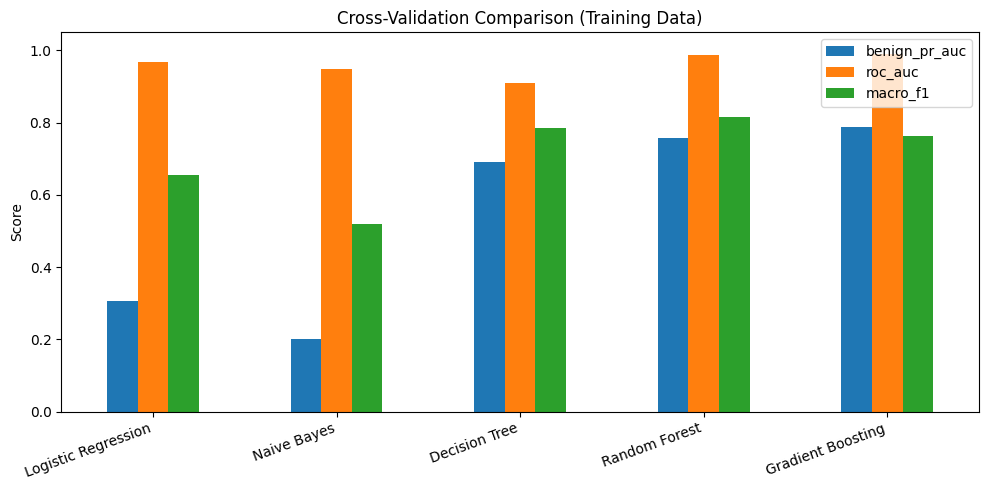

Best candidate by cross-validated benign PR-AUC: Gradient Boosting


In [23]:
cv_table.drop(index="Dummy Baseline")[["benign_pr_auc", "roc_auc", "macro_f1"]].plot(
    kind="bar", figsize=(10, 5))
plt.title("Cross-Validation Comparison (Training Data)")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

leading = cv_table.drop(index="Dummy Baseline")["benign_pr_auc"].idxmax()
print(f"Best candidate by cross-validated benign PR-AUC: {leading}")

**8. Hyperparameter Tuning (Random Forest and Gradient Boosting)**

The two strongest tree-based candidates are each tuned on benign PR-AUC (a grid search for Random Forest and a randomized search for Gradient Boosting), using the training set only. Each best setting is refit on the full training set automatically. The model with the higher cross-validated benign PR-AUC becomes the final model, and its threshold is chosen in section 9.

In [24]:
if QUICK_RUN:
    rf_grid = {"n_estimators": [100], "max_depth": [20, None], "min_samples_leaf": [2, 5],
               "max_features": ["sqrt"], "max_samples": [0.3]}
    hgb_iter = 4
else:
    rf_grid = {
        "n_estimators": [200, 300],
        "max_depth": [10, 20, None],
        "min_samples_leaf": [1, 2, 5, 10],
        "max_features": ["sqrt", 0.5],
        "max_samples": [0.3, 0.6],
    }
    hgb_iter = 10

rf_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE),
    param_grid=rf_grid,
    scoring=benign_pr_auc, cv=cv5, refit=True, verbose=1,
)

hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    param_distributions={
        "learning_rate": [0.03, 0.05, 0.1, 0.2],
        "max_iter": [100, 200, 300],
        "max_leaf_nodes": [15, 31, 63],
        "max_depth": [None, 6, 10],
        "min_samples_leaf": [10, 20, 50],
        "l2_regularization": [0.0, 0.1, 1.0],
    },
    n_iter=hgb_iter, scoring=benign_pr_auc, cv=cv5, refit=True, random_state=RANDOM_STATE, verbose=1,
)

searches = {"Random Forest": rf_search, "Gradient Boosting": hgb_search}
for name, srch in searches.items():
    srch.fit(x_train, y_train, groups=g_train)
    print(f"\n{name}: best cross-validated benign PR-AUC = {srch.best_score_:.4f}")
    print("  best parameters:", srch.best_params_)

final_name = max(searches, key=lambda k: searches[k].best_score_)
final_model = searches[final_name].best_estimator_
print(f"\nFinal model: {final_name}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Random Forest: best cross-validated benign PR-AUC = 0.7694
  best parameters: {'max_depth': None, 'max_features': 0.5, 'max_samples': 0.6, 'min_samples_leaf': 5, 'n_estimators': 300}
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Gradient Boosting: best cross-validated benign PR-AUC = 0.7899
  best parameters: {'min_samples_leaf': 20, 'max_leaf_nodes': 15, 'max_iter': 200, 'max_depth': 6, 'learning_rate': 0.2, 'l2_regularization': 0.0}

Final model: Gradient Boosting


**9. Choose the Decision Threshold (Training Data Only)**

The default rule (predict phishing when probability is at least 0.5) is not necessarily best when 99.5% of the data is phishing. Thresholds are evaluated on **out-of-fold** predictions from the training set, so the test set stays untouched.

Two choices are compared:
- **Macro F1 threshold:** the threshold with the best macro F1.
- **Goal threshold (used as the final one):** the threshold with the highest phishing recall among those that keep benign recall at or above a target. This controls false alarms on legitimate sites directly.

Macro F1 threshold : 0.05
Goal threshold     : 0.25  (benign recall >= 90%)

Out-of-fold results at the candidate thresholds:
           benign_recall  phishing_recall  macro_f1
threshold                                          
0.05              0.6776           0.9928    0.8366
0.25              0.9006           0.9716    0.7791
0.50              0.9517           0.9603    0.7480


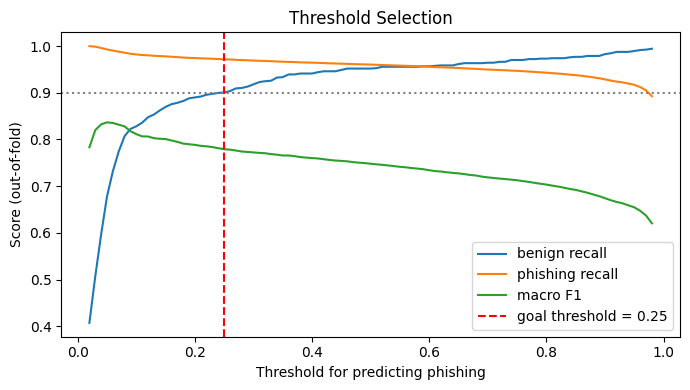

In [25]:
TARGET_BENIGN_RECALL = 0.90   # change this to trade false alarms against missed phishing

oof_proba = cross_val_predict(clone(final_model), x_train, y_train, cv=cv5, groups=g_train, method="predict_proba")[:, 1]

thresholds = np.round(np.arange(0.02, 0.99, 0.01), 2)
rows = []
for t in thresholds:
    p = (oof_proba >= t).astype(int)
    rows.append({"threshold": t,
                 "benign_recall": recall_score(y_train, p, pos_label=0),
                 "phishing_recall": recall_score(y_train, p, pos_label=1),
                 "macro_f1": f1_score(y_train, p, average="macro")})
thr_table = pd.DataFrame(rows)

f1_threshold = float(thr_table.loc[thr_table["macro_f1"].idxmax(), "threshold"])

eligible = thr_table[thr_table["benign_recall"] >= TARGET_BENIGN_RECALL]
if len(eligible) > 0:
    pick = eligible.sort_values(["phishing_recall", "macro_f1"], ascending=False).iloc[0]
else:
    print(f"No threshold reaches benign recall {TARGET_BENIGN_RECALL:.0%}; falling back to the macro F1 threshold.")
    pick = thr_table.loc[thr_table["macro_f1"].idxmax()]
final_threshold = float(pick["threshold"])

print(f"Macro F1 threshold : {f1_threshold:.2f}")
print(f"Goal threshold     : {final_threshold:.2f}  (benign recall >= {TARGET_BENIGN_RECALL:.0%})")
print("\nOut-of-fold results at the candidate thresholds:")
print(thr_table.set_index("threshold").loc[sorted({0.5, round(f1_threshold, 2), round(final_threshold, 2)})].round(4))

plt.figure(figsize=(7, 4))
plt.plot(thr_table["threshold"], thr_table["benign_recall"], label="benign recall")
plt.plot(thr_table["threshold"], thr_table["phishing_recall"], label="phishing recall")
plt.plot(thr_table["threshold"], thr_table["macro_f1"], label="macro F1")
plt.axvline(final_threshold, color="red", linestyle="--", label=f"goal threshold = {final_threshold:.2f}")
plt.axhline(TARGET_BENIGN_RECALL, color="gray", linestyle=":")
plt.xlabel("Threshold for predicting phishing")
plt.ylabel("Score (out-of-fold)")
plt.title("Threshold Selection")
plt.legend()
plt.tight_layout()
plt.show()

**10. Final Evaluation on the Held-Out Test Set**

This is the only time the test set is used to score the finished model. The tuned model is compared with the dummy baseline and with the untuned Random Forest setup from the initial training run.

In [26]:
def evaluate(name, y_true, preds):
    accuracy = accuracy_score(y_true, preds)
    precision = precision_score(y_true, preds, pos_label=1, zero_division=0)
    recall = recall_score(y_true, preds, pos_label=1)
    f1 = f1_score(y_true, preds, pos_label=1)
    macro_f1 = f1_score(y_true, preds, average="macro")

    cm = confusion_matrix(y_true, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    benign_recall = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    print(f"\n=== {name} ===")
    print(f"Accuracy : {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall   : {recall*100:.2f}%")
    print(f"F1 Score : {f1*100:.2f}%  (phishing class only)")
    print(f"Macro F1 : {macro_f1*100:.2f}%  (both classes weighted equally)")
    print(f"False Positive Rate: {fpr*100:.2f}%")
    print(f"Benign Recall: {benign_recall*100:.2f}%")
    print(f"Confusion Matrix:\n{cm}")

    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1 Score": f1,
            "Macro F1": macro_f1, "False Positive Rate": fpr, "Benign Recall": benign_recall}

# reference models
dummy = DummyClassifier(strategy="most_frequent").fit(x_train, y_train)
initial_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1,
                                    random_state=RANDOM_STATE).fit(x_train, y_train)

test_proba = final_model.predict_proba(x_test)[:, 1]

results = {
    "Dummy Baseline": evaluate("Dummy Baseline", y_test, dummy.predict(x_test)),
    "Initial Random Forest": evaluate("Initial Random Forest (untuned)", y_test, initial_rf.predict(x_test)),
    f"Tuned {final_name} (0.50)": evaluate(f"Tuned {final_name}, threshold 0.50", y_test, (test_proba >= 0.5).astype(int)),
    f"Tuned {final_name} (macro F1 thr {f1_threshold:.2f})": evaluate(
        f"Tuned {final_name}, macro F1 threshold {f1_threshold:.2f}", y_test, (test_proba >= f1_threshold).astype(int)),
    f"Tuned {final_name} (goal thr {final_threshold:.2f})": evaluate(
        f"Tuned {final_name}, goal threshold {final_threshold:.2f} (FINAL)", y_test, (test_proba >= final_threshold).astype(int)),
}

print(f"\nROC-AUC (tuned model)            : {roc_auc_score(y_test, test_proba):.4f}")
print(f"PR-AUC for the benign class      : {average_precision_score(1 - y_test, 1 - test_proba):.4f}")


=== Dummy Baseline ===
Accuracy : 98.57%
Precision: 98.57%
Recall   : 100.00%
F1 Score : 99.28%  (phishing class only)
Macro F1 : 49.64%  (both classes weighted equally)
False Positive Rate: 100.00%
Benign Recall: 0.00%
Confusion Matrix:
[[    0   164]
 [    0 11281]]

=== Initial Random Forest (untuned) ===
Accuracy : 97.89%
Precision: 99.75%
Recall   : 98.11%
F1 Score : 98.92%  (phishing class only)
Macro F1 : 75.97%  (both classes weighted equally)
False Positive Rate: 17.07%
Benign Recall: 82.93%
Confusion Matrix:
[[  136    28]
 [  213 11068]]

=== Tuned Gradient Boosting, threshold 0.50 ===
Accuracy : 93.88%
Precision: 99.95%
Recall   : 93.84%
F1 Score : 96.80%  (phishing class only)
Macro F1 : 64.02%  (both classes weighted equally)
False Positive Rate: 3.05%
Benign Recall: 96.95%
Confusion Matrix:
[[  159     5]
 [  695 10586]]

=== Tuned Gradient Boosting, macro F1 threshold 0.05 ===
Accuracy : 99.06%
Precision: 99.69%
Recall   : 99.35%
F1 Score : 99.52%  (phishing class only

In [27]:
final_comparison = pd.DataFrame(results).T.round(4)
final_comparison

,Accuracy,Precision,Recall,F1 Score,Macro F1,False Positive Rate,Benign Recall
Dummy Baseline,0.9857,0.9857,1.0000,0.9928,0.4964,1.0000,0.0000
Initial Random Forest,0.9789,0.9975,0.9811,0.9892,0.7597,0.1707,0.8293
Tuned Gradient Boosting (0.50),0.9388,0.9995,0.9384,0.9680,0.6402,0.0305,0.9695
Tuned Gradient Boosting (macro F1 thr 0.05),0.9906,0.9969,0.9935,0.9952,0.8501,0.2134,0.7866
Tuned Gradient Boosting (goal thr 0.25),0.9596,0.9989,0.9601,0.9791,0.6880,0.0732,0.9268


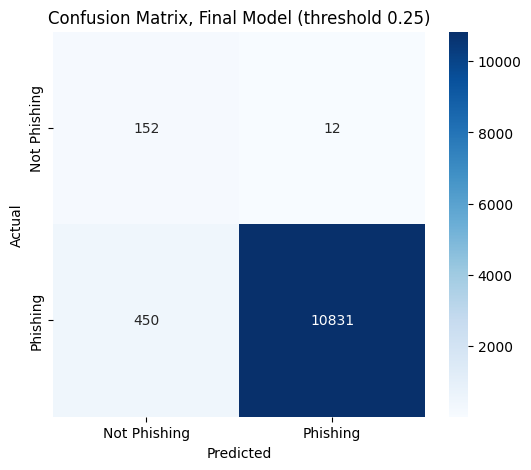

In [28]:
final_preds = (test_proba >= final_threshold).astype(int)
cm = confusion_matrix(y_test, final_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Phishing", "Phishing"], yticklabels=["Not Phishing", "Phishing"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix, Final Model (threshold {final_threshold:.2f})")
plt.show()

**10.5. Evaluate the Full System (Rules + Model)**

The model alone is scored above on the untouched test set. The system the app actually uses applies the rules from section 3.7 first and lets the model decide the rest. It is checked three ways: on the test set, on legitimate hosts the model never saw in training, and on a hand-written spot-check list that includes the examples from the course feedback.

In [29]:
def system_predict(hosts, probs, thr):
    """1 = phishing. Rules decide first; the model decides what the rules do not cover."""
    out, source = [], []
    for h, p in zip(hosts, probs):
        r = rule_verdict(h)
        if r:
            out.append(int(r[0] == "phishing")); source.append(r[1])
        else:
            out.append(int(p >= thr)); source.append("model")
    return np.array(out), pd.Series(source)

test_hosts = df.loc[x_test.index, "host"].tolist()
sys_preds, sys_source = system_predict(test_hosts, test_proba, final_threshold)
print("Who decided each test row:", sys_source.value_counts().to_dict())
hybrid_results = {
    "Model only": evaluate("Model only (test set)", y_test, (test_proba >= final_threshold).astype(int)),
    "Rules + model": evaluate("Rules + model (test set)", y_test, sys_preds),
}
print(f"\nPhishing rows hosted on trusted domains in the full dataset: {len(df_ambiguous)}. The system calls those hosts "
      "not phishing by design, because the host alone cannot show that the page is malicious.")

# legitimate hosts the model never saw in training
def build_X(hosts):
    f = pd.DataFrame([host_features(h) for h in hosts])
    f["tld_freq"] = f["tld"].map(tld_freq_map).fillna(0.0)
    return f[x_train.columns]
ho_proba = final_model.predict_proba(build_X(holdout_hosts))[:, 1]
ho_sys, _ = system_predict(holdout_hosts, ho_proba, final_threshold)
print(f"\nUnseen legitimate hosts ({len(holdout_hosts)}): model alone calls {(ho_proba < final_threshold).mean():.1%} "
      f"not phishing; rules + model call {(ho_sys == 0).mean():.1%} not phishing")
print("Model alone still flags:", [h for h, p in zip(holdout_hosts, ho_proba) if p >= final_threshold][:15])

# spot-check list (label: 0 = legitimate, 1 = phishing)
SPOT_CHECK = [
    ("github.com", 0), ("https://github.com/login", 0), ("chatgpt.com", 0), ("https://chatgpt.com/c/123", 0),
    ("openai.com", 0), ("google.com", 0), ("https://www.google.com/search?q=test", 0), ("docs.google.com", 0),
    ("wikipedia.org", 0), ("en.wikipedia.org", 0), ("python.org", 0), ("mozilla.org", 0), ("kaggle.com", 0),
    ("linkedin.com", 0), ("login.microsoftonline.com", 0), ("accounts.google.com", 0), ("streamlit.io", 0),
    ("up.edu.ph", 0), ("umindanao.edu.ph", 0), ("pup.edu.ph", 0), ("deped.gov.ph", 0), ("dost.gov.ph", 0),
    ("mit.edu", 0), ("ateneo.edu", 0), ("bdo.com.ph", 0), ("gcash.com", 0), ("shopee.ph", 0),
    ("lazada.com.ph", 0), ("abs-cbn.com", 0), ("rappler.com", 0), ("pcij.org", 0), ("gutenberg.org", 0),
    ("secure-login-paypal.verify-account.xyz", 1), ("http://secure-login-paypal.verify-account.xyz/update", 1),
    ("http://192.168.10.5/login", 1), ("http://103.20.213.34/bank/login.php", 1), ("paypal.com.account-verify.xyz", 1),
    ("g00gle-login.top", 1), ("gcash-verify-login.xyz", 1), ("bdo-online-secure.com", 1), ("bpi-update-account.top", 1),
    ("chatgpt-free-login.xyz", 1), ("github-login-verify.xyz", 1), ("microsoft-support-alert.top", 1),
    ("netflix-billing-update.com", 1), ("amaz0n-secure.online", 1), ("shopee-ph-promo.xyz", 1),
    ("lazada-ph-verify.top", 1), ("dhl-parcel-confirm.xyz", 1), ("google.com.verify-session.xyz", 1),
    ("paypal-help.ph", 1), ("appleid-apple.com-verify.xyz", 1),
]
rows = []
for u, truth in SPOT_CHECK:
    h = normalize_host(u)
    p = float(final_model.predict_proba(build_X([h]))[0, 1])
    r = rule_verdict(h)
    pred = int(r[0] == "phishing") if r else int(p >= final_threshold)
    rows.append({"url": u, "expected": "phishing" if truth else "legitimate", "model_prob": round(p, 3),
                 "decided_by": r[1] if r else "model", "predicted": "phishing" if pred else "legitimate",
                 "correct": pred == truth})
spot = pd.DataFrame(rows)
print(f"\nSpot-check accuracy: {spot['correct'].mean():.1%} ({spot['correct'].sum()}/{len(spot)})")
spot[~spot["correct"]]

Who decided each test row: {'model': 11337, 'trusted domain list': 44, 'institutional domain rule': 38, 'brand impersonation rule': 26}

=== Model only (test set) ===
Accuracy : 95.96%
Precision: 99.89%
Recall   : 96.01%
F1 Score : 97.91%  (phishing class only)
Macro F1 : 68.80%  (both classes weighted equally)
False Positive Rate: 7.32%
Benign Recall: 92.68%
Confusion Matrix:
[[  152    12]
 [  450 10831]]

=== Rules + model (test set) ===
Accuracy : 95.94%
Precision: 99.94%
Recall   : 95.94%
F1 Score : 97.90%  (phishing class only)
Macro F1 : 69.10%  (both classes weighted equally)
False Positive Rate: 4.27%
Benign Recall: 95.73%
Confusion Matrix:
[[  157     7]
 [  458 10823]]

Phishing rows hosted on trusted domains in the full dataset: 11708. The system calls those hosts not phishing by design, because the host alone cannot show that the page is malicious.

Unseen legitimate hosts (123): model alone calls 90.2% not phishing; rules + model call 100.0% not phishing
Model alone still

,url,expected,model_prob,decided_by,predicted,correct


**11. Stability Check (5-Fold Cross-Validation on Training Data)**


A small standard deviation means the result does not depend on one lucky or unlucky split.

In [30]:
stab = cross_validate(clone(final_model), x_train, y_train, cv=cv5, scoring=scoring, groups=g_train)

for key in ["macro_f1", "benign_recall", "phishing_recall"]:
    s = stab[f"test_{key}"]
    print(f"{key:16s}: {np.round(s, 4)}  mean {s.mean()*100:.2f}% (+/- {s.std()*100:.2f}%)")

macro_f1        : [0.764  0.7492 0.7335 0.7512 0.7444]  mean 74.85% (+/- 0.99%)
benign_recall   : [0.9517 0.9517 0.9856 0.9324 0.9372]  mean 95.17% (+/- 1.86%)
phishing_recall : [0.9649 0.9607 0.9532 0.9624 0.9601]  mean 96.03% (+/- 0.39%)


**12. Feature Importance**

Permutation importance on the test set shows how much performance drops when one feature is shuffled. The model's built-in importance is added when the final model provides it (Random Forest does, Gradient Boosting does not).

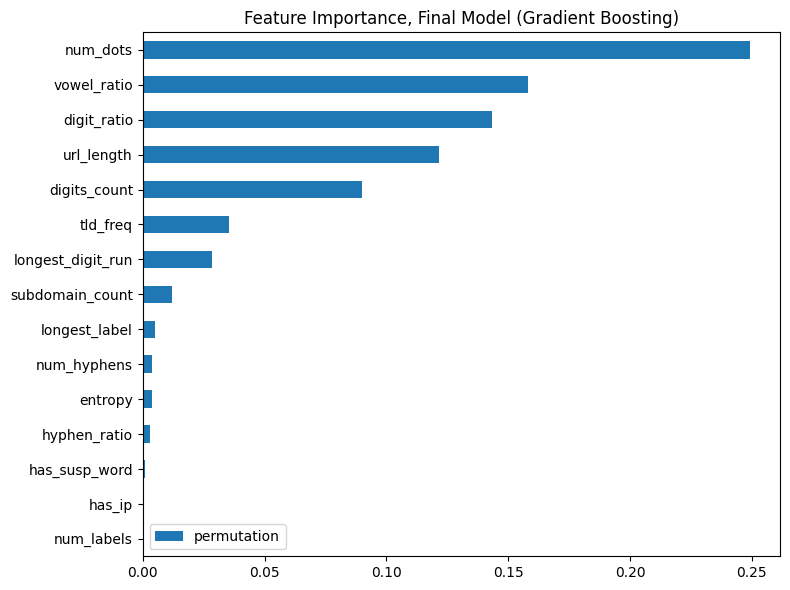

,permutation
num_dots,0.249086
vowel_ratio,0.158221
digit_ratio,0.143268
url_length,0.121558
digits_count,0.089971
tld_freq,0.035399
longest_digit_run,0.028301
subdomain_count,0.012186
longest_label,0.004946
num_hyphens,0.003772


In [31]:
perm = permutation_importance(final_model, x_test, y_test, scoring="balanced_accuracy",
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)

importance_table = pd.DataFrame({"permutation": perm.importances_mean}, index=x_train.columns)
if hasattr(final_model, "feature_importances_"):
    importance_table["built_in"] = final_model.feature_importances_
importance_table = importance_table.sort_values("permutation", ascending=False)

importance_table.plot(kind="barh", figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title(f"Feature Importance, Final Model ({final_name})")
plt.tight_layout()
plt.show()

importance_table

**13. Save the Final Model and Add a Prediction Function**

The saved file bundles everything needed at prediction time: the model, the chosen threshold, the training-set TLD frequency map, and the feature order. predict_url rebuilds the same host-based features for a single raw URL, and a quick check confirms it matches the features used in training.

In [32]:
FEATURE_ORDER = x_train.columns.tolist()

artifact = {
    "model": final_model,
    "model_name": final_name,
    "threshold": final_threshold,
    "tld_freq_map": tld_freq_map.to_dict(),
    "feature_order": FEATURE_ORDER,
    # curated knowledge used by the rules (section 3.7)
    "trusted_domains": sorted(TRUSTED_DOMAINS),
    "shared_platform_hosts": sorted(SHARED_PLATFORM_HOSTS),
    "institution_pattern": INSTITUTION_RE.pattern,
    "brand_official": BRAND_OFFICIAL,
    "strong_brands": sorted(STRONG_BRANDS),
    "abused_tlds": sorted(ABUSED_TLDS),
    "legit_reference": {c: float(x_train.loc[y_train == 0, c].median()) for c in FEATURE_ORDER if c != "tld_freq"},
}

def build_row(url, artifact=artifact):
    f = host_features(normalize_host(url))
    row = {c: f[c] for c in feature_cols}
    row["tld_freq"] = artifact["tld_freq_map"].get(f["tld"], 0.0)
    return pd.DataFrame([row])[artifact["feature_order"]]

def predict_url(url, artifact=artifact):
    p = float(artifact["model"].predict_proba(build_row(url, artifact))[0, 1])
    return {"url": url, "phishing_probability": round(p, 4),
            "prediction": "phishing" if p >= artifact["threshold"] else "not phishing"}

def classify_url(url, artifact=artifact):
    """Final system: rules first (trusted list, brand impersonation, institutional suffix), then the model."""
    host = normalize_host(url)
    p = float(artifact["model"].predict_proba(build_row(url, artifact))[0, 1])
    r = rule_verdict(host)
    label, by, why = r if r else ("phishing" if p >= artifact["threshold"] else "not phishing", "model", "")
    return {"url": url, "host": host, "prediction": label, "decided_by": by,
            "model_probability": round(p, 4), "reason": why}

# sanity check: rebuilding features from the raw URL must match the test features used in training
check_idx = x_test.sample(300, random_state=RANDOM_STATE).index
mismatches = 0
for idx in check_idx:
    rebuilt = build_row(df.loc[idx, "url"]).iloc[0].astype(float).values
    original = x_test.loc[idx, FEATURE_ORDER].astype(float).values
    if not np.allclose(rebuilt, original):
        mismatches += 1
print("Rows where predict_url features differ from training features:", mismatches)

joblib.dump(artifact, "phishing_model.joblib")
print("Saved: phishing_model.joblib")

for u in ["https://www.google.com/search?q=test",
          "google.com",
          "github.com",
          "http://192.168.10.5/login",
          "http://secure-login-paypal.verify-account.xyz/update",
          "chatgpt.com", "up.edu.ph", "https://www.deped.gov.ph", "paypal.com.account-verify.xyz"]:
    print(classify_url(u))

Rows where predict_url features differ from training features: 0
Saved: phishing_model.joblib
{'url': 'https://www.google.com/search?q=test', 'host': 'google.com', 'prediction': 'not phishing', 'decided_by': 'trusted domain list', 'model_probability': 0.0215, 'reason': 'This is a known legitimate domain.'}
{'url': 'google.com', 'host': 'google.com', 'prediction': 'not phishing', 'decided_by': 'trusted domain list', 'model_probability': 0.0215, 'reason': 'This is a known legitimate domain.'}
{'url': 'github.com', 'host': 'github.com', 'prediction': 'not phishing', 'decided_by': 'trusted domain list', 'model_probability': 0.0403, 'reason': 'This is a known legitimate domain.'}
{'url': 'http://192.168.10.5/login', 'host': '192.168.10.5', 'prediction': 'phishing', 'decided_by': 'model', 'model_probability': 0.9998, 'reason': ''}
{'url': 'http://secure-login-paypal.verify-account.xyz/update', 'host': 'secure-login-paypal.verify-account.xyz', 'prediction': 'phishing', 'decided_by': 'brand im

**14. Notes and Limitations**

- The benign class has only 820 rows (about 164 in the test set), so every benign metric, including false positive rate, has a wide margin of error. One or two test rows can move it by a full percentage point.
- Benign URLs are bare domains and phishing URLs are full URLs, so all features are computed from the host name only. Path, query, and scheme information was removed on purpose (see sections 3 to 3.6).
- Train and test rows never share a registered domain (grouped split in section 5), and the cross-validation folds are grouped the same way. Scores are therefore lower than a random split would give, and closer to what new domains would see. Base domains are found with a simple rule (last two labels, or three for patterns like co.uk), not a full public-suffix list.
- A leading "www." is stripped from every host, since no benign host in the data has one and the model would otherwise learn it as a phishing signal.
- The final threshold is chosen on training data to keep benign recall at or above the target in section 9. Lower the target to catch more phishing, or raise it to flag fewer legitimate sites.
- Results describe how well the model separates this dataset's phishing hosts from this dataset's benign hosts. Real-world performance on other benign sites is not guaranteed. More diverse benign data would be the most useful improvement.
- To use the model elsewhere, load it with joblib.load("phishing_model.joblib"). The saved file holds the model, the threshold and the curated rule data; app.py contains the matching feature and rule code.
- The trusted-domain list, brand list and institutional-suffix rule are hand-written knowledge, not learned. A legitimate site that is on none of them is decided by the model alone, and a brand missing from the brand list is not caught by the impersonation rule. The lists should be extended over time.
- Pages on shared platforms (github.com, docs.google.com, sites.google.com) are reported as not phishing because the host is legitimate. A malicious page on such a platform cannot be detected from the host name; the app shows a caution note for these hosts.
- Rows were deduplicated by host and label before modelling (section 3.7), so every host counts once and the test-set scores describe unique hosts, which is a harder and more honest test than counting the same host thousands of times.
- Open endings (.org, .com, plain .ph) are not trusted by suffix: the dataset has more than a thousand phishing hosts on .org alone. Only restricted endings (.edu, .gov, .mil, .edu.ph, .gov.ph, .ac.xx) are trusted by rule.

**15. Conclusion**

- **Problem found:** the dataset labels about 1,560 github.com rows and thousands of docs.google.com rows as phishing (pages hosted there), so a host-only model learned that well-known legitimate hosts look like phishing. Legitimate .ph, .org and .edu hosts were also rare in the benign list.
- **Fixes (CSV untouched):** host-level deduplication (each host counts once), a trusted-domain list, a rule for institutional endings (.edu, .gov, .edu.ph, .gov.ph, .ac.xx), a brand-impersonation rule, curated legitimate hosts added to training only, and public-suffix-aware features so edu.ph and com.ph are not treated as plain .ph.
- **Final model and results:** printed by the next cell from the actual run, so the numbers always match the saved model.
- **Main weakness:** a legitimate site that is not on any list is decided by the model alone, and the model was trained on few legitimate hosts. Pages on shared platforms cannot be judged from the host name.
- **Next step:** add a larger, more varied list of legitimate domains collected the same way as the phishing URLs, and retrain.

In [33]:
m = hybrid_results["Model only"]; s = hybrid_results["Rules + model"]
print(f"Final model: {final_name}, threshold {final_threshold:.2f}")
print(f"Model only    : phishing recall {m['Recall']:.1%}, benign recall {m['Benign Recall']:.1%}, macro F1 {m['Macro F1']:.1%}")
print(f"Rules + model : phishing recall {s['Recall']:.1%}, benign recall {s['Benign Recall']:.1%}, macro F1 {s['Macro F1']:.1%}")
print(f"Unseen legitimate hosts called not phishing by the model alone: {(ho_proba < final_threshold).mean():.1%}")
print(f"Spot-check accuracy (rules + model): {spot['correct'].mean():.1%} ({spot['correct'].sum()}/{len(spot)})")
print(f"Rows after host deduplication: {len(df)} (unique host/label pairs)")

Final model: Gradient Boosting, threshold 0.25
Model only    : phishing recall 96.0%, benign recall 92.7%, macro F1 68.8%
Rules + model : phishing recall 95.9%, benign recall 95.7%, macro F1 69.1%
Unseen legitimate hosts called not phishing by the model alone: 90.2%
Spot-check accuracy (rules + model): 100.0% (52/52)
Rows after host deduplication: 57227 (unique host/label pairs)
